In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def simulate(N=100, S=10, f=0.3, p=0.0, trials=5000):
    compromised_count = 0
    total_overhead = 0  # NEW: sum of validator-shard assignments

    for _ in range(trials):
        validators = list(range(N))
        attackers = set(random.sample(validators, int(f * N)))

        shards = {i: [] for i in range(S)}

        # Primary assignment
        for v in validators:
            shard = random.randint(0, S-1)
            shards[shard].append(v)
            total_overhead += 1  # count this assignment

        # Overlap assignment
        for v in validators:
            if random.random() < p:
                shard = random.randint(0, S-1)
                shards[shard].append(v)
                total_overhead += 1  # count this extra assignment

        # Check compromise
        compromised = False
        for shard_vals in shards.values():
            if len(shard_vals) == 0:
                continue
            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            attacker_ratio = attackers_in_shard / len(shard_vals)

            # Nakamoto-style compromise probability
            attack_prob = nakamoto_attack_success_prob(attacker_ratio, confirmations)

            if random.random() < attack_prob:
                compromised = True

        if compromised:
            compromised_count += 1

    compromise_prob = compromised_count / trials
    avg_overhead = total_overhead / trials  # average assignments per trial
    return compromise_prob, avg_overhead


ps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []
overheads = []

for p in ps:
    prob, overhead = simulate(p=p)
    results.append(prob)
    overheads.append(overhead)

# 📊 Print table
print("\nEffect of Validator Overlap on Shard Compromise Probability\n")
print("------------------------+-------------------------------+-------------------------------")
print("| Overlap Probability   | Compromise Probability        | Overhead                     |")
print("------------------------+-------------------------------+-------------------------------")

for p, r, o in zip(ps, results, overheads):
    print(f"| {p:<22}| {r:<29.3f} | {o:<25.2f}    |")

print("------------------------+-------------------------------+-------------------------------")

# 📈 Plot graph
plt.figure(figsize=(6,4))
plt.plot(ps, results, marker='o', linewidth=2)

plt.title("Validator Overlap vs Shard Compromise Probability")
plt.xlabel("Overlap Probability")
plt.ylabel("Compromise Probability")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_security.png")  # saves image
plt.show()



plt.figure(figsize=(6,4))
plt.plot(ps, overheads, marker='o', linewidth=2)

plt.title("Validator Overlap vs Overhead")
plt.xlabel("Overlap Probability")
plt.ylabel("Overhead")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_overhead.png")  # saves image
plt.show()


NameError: name 'nakamoto_attack_success_prob' is not defined


Effect of Validator Overlap on Shard Compromise Probability

------------------------+-------------------------------+-------------------------------
| Overlap Probability   | Compromise Probability        | Overhead                     |
------------------------+-------------------------------+-------------------------------
| 0.0                   | 0.995                         | 10.00                        |
| 0.1                   | 0.975                         | 100.00                       |
| 0.2                   | 0.876                         | 199.96                       |
| 0.3                   | 0.691                         | 299.88                       |
| 0.4                   | 0.480                         | 399.85                       |
| 0.5                   | 0.245                         | 499.95                       |
| 0.6                   | 0.093                         | 599.86                       |
| 0.7                   | 0.018                 

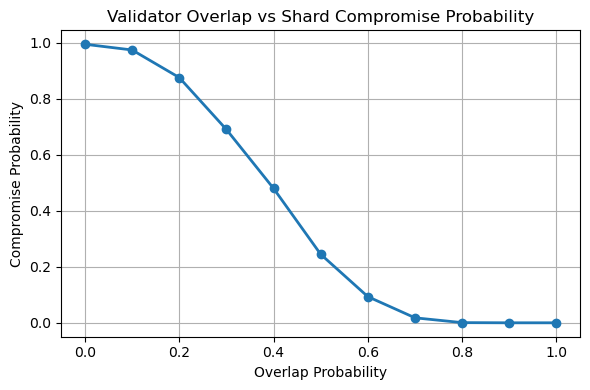

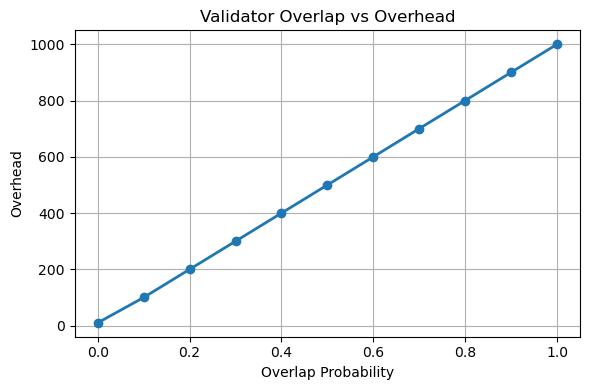

In [39]:
def simulate_v2(N=100, S=10, f=0.4, p=0.3, a=.5, trials=5000):
    compromised_count = 0
    total_overhead = 0  # total assignments per trial

    for _ in range(trials):
        validators = list(range(N))
        attackers = set(random.sample(validators, int(f * N)))

        shards = {i: [] for i in range(S)}

        # Each validator considers EACH shard
        for v in validators:
            for s in range(S):
                if random.random() < p:
                    shards[s].append(v)
                    total_overhead += 1

        # Avoid empty shards (important edge case)
        for s in range(S):
            if len(shards[s]) == 0:
                v = random.choice(validators)
                shards[s].append(v)
                total_overhead += 1

        # Check compromise
        compromised = False
        for shard_vals in shards.values():
            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            if attackers_in_shard / len(shard_vals) >= a:
                compromised = True
                break

        if compromised:
            compromised_count += 1

    compromise_prob = compromised_count / trials
    avg_overhead = total_overhead / trials
    return compromise_prob, avg_overhead



ps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []
overheads = []

for p in ps:
    prob, overhead = simulate_v2(p=p)
    results.append(prob)
    overheads.append(overhead)

# 📊 Print table
print("\nEffect of Validator Overlap on Shard Compromise Probability\n")
print("------------------------+-------------------------------+-------------------------------")
print("| Overlap Probability   | Compromise Probability        | Overhead                     |")
print("------------------------+-------------------------------+-------------------------------")

for p, r, o in zip(ps, results, overheads):
    print(f"| {p:<22}| {r:<29.3f} | {o:<25.2f}    |")

print("------------------------+-------------------------------+-------------------------------")

# 📈 Plot graph
plt.figure(figsize=(6,4))
plt.plot(ps, results, marker='o', linewidth=2)

plt.title("Validator Overlap vs Shard Compromise Probability")
plt.xlabel("Overlap Probability")
plt.ylabel("Compromise Probability")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_security.png")  # saves image
plt.show()



plt.figure(figsize=(6,4))
plt.plot(ps, overheads, marker='o', linewidth=2)

plt.title("Validator Overlap vs Overhead")
plt.xlabel("Overlap Probability")
plt.ylabel("Overhead")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_overhead.png")  # saves image
plt.show()


Attempt limited number of validators per shard


Effect of Validator Overlap on Shard Compromise Probability

------------------------+-------------------------------+-------------------------------
| Overlap Probability   | Compromise Probability        | Overhead                     |
------------------------+-------------------------------+-------------------------------
| 0.0                   | 0.100                         | 600.00                       |
| 0.1                   | 0.099                         | 623.94                       |
| 0.2                   | 0.104                         | 648.00                       |
| 0.3                   | 0.103                         | 672.08                       |
| 0.4                   | 0.096                         | 695.77                       |
| 0.5                   | 0.096                         | 720.19                       |
| 0.6                   | 0.097                         | 744.12                       |
| 0.7                   | 0.101                 

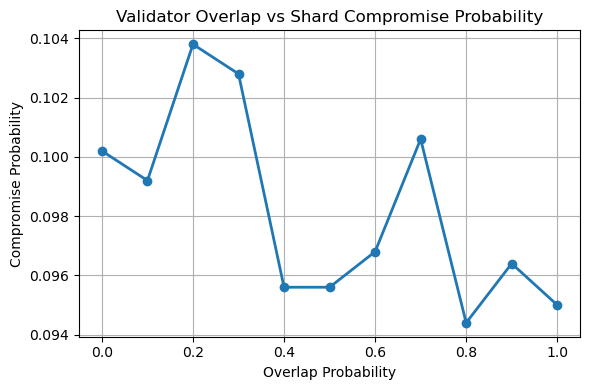

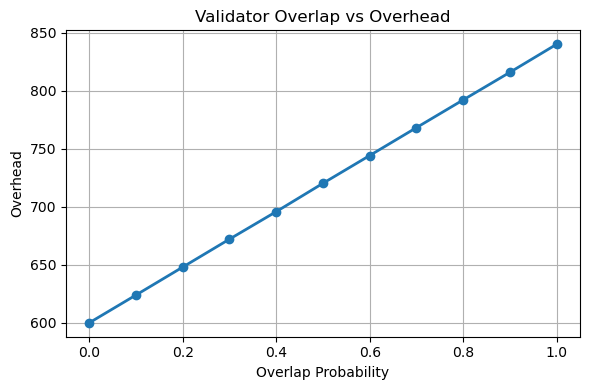

In [38]:
import random

def simulate_overlap_k(N=100, S=10, k=60, f=0.4, p=0.3, a = .5, trials=5000):
    compromised_count = 0
    total_overhead = 0

    for _ in range(trials):
        validators = list(range(N))
        attackers = set(random.sample(validators, int(f * N)))

        shards = {s: [] for s in range(S)}

        # Step 1: assign exactly k validators per shard, including attackers proportionally
        for s in range(S):
            shard_vals = random.sample(validators, k)
            shards[s] = shard_vals
            total_overhead += k

        # Step 2: overlap only applies to honest validators
        honest_validators = [v for v in validators if v not in attackers]
        for v in honest_validators:
            for s in range(S):
                if random.random() < p and v not in shards[s]:
                    shards[s].append(v)
                    total_overhead += 1

        # 🔑 Step 3: check compromise
        compromised = False
        for shard_vals in shards.values():
            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            if attackers_in_shard / k >= a:
                compromised = True
                break

        if compromised:
            compromised_count += 1

    return compromised_count / trials, total_overhead / trials

ps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []
overheads = []

for p in ps:
    prob, overhead = simulate_overlap_k(p=p)
    results.append(prob)
    overheads.append(overhead)

# 📊 Print table
print("\nEffect of Validator Overlap on Shard Compromise Probability\n")
print("------------------------+-------------------------------+-------------------------------")
print("| Overlap Probability   | Compromise Probability        | Overhead                     |")
print("------------------------+-------------------------------+-------------------------------")

for p, r, o in zip(ps, results, overheads):
    print(f"| {p:<22}| {r:<29.3f} | {o:<25.2f}    |")

print("------------------------+-------------------------------+-------------------------------")

# 📈 Plot graph
plt.figure(figsize=(6,4))
plt.plot(ps, results, marker='o', linewidth=2)

plt.title("Validator Overlap vs Shard Compromise Probability")
plt.xlabel("Overlap Probability")
plt.ylabel("Compromise Probability")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_security.png")  # saves image
plt.show()



plt.figure(figsize=(6,4))
plt.plot(ps, overheads, marker='o', linewidth=2)

plt.title("Validator Overlap vs Overhead")
plt.xlabel("Overlap Probability")
plt.ylabel("Overhead")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_overhead.png")  # saves image
plt.show()

Attempt to do adversarial


Effect of Validator Overlap on Shard Compromise Probability

------------------------+-------------------------------+-------------------------------
| Overlap Probability   | Compromise Probability        | Overhead                     |
------------------------+-------------------------------+-------------------------------
| 0.0                   | 1.000                         | 102.91                       |
| 0.1                   | 1.000                         | 163.86                       |
| 0.2                   | 1.000                         | 232.06                       |
| 0.3                   | 1.000                         | 299.86                       |
| 0.4                   | 1.000                         | 367.86                       |
| 0.5                   | 1.000                         | 436.15                       |
| 0.6                   | 0.944                         | 503.96                       |
| 0.7                   | 0.405                 

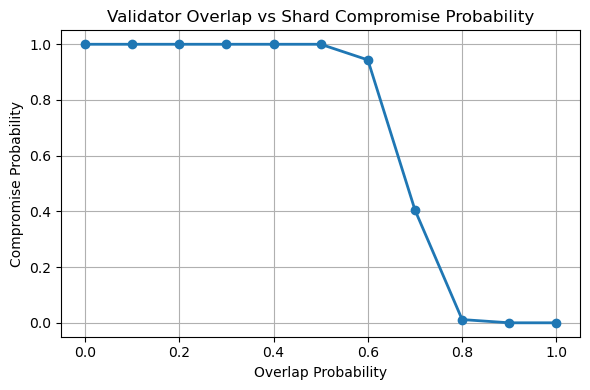

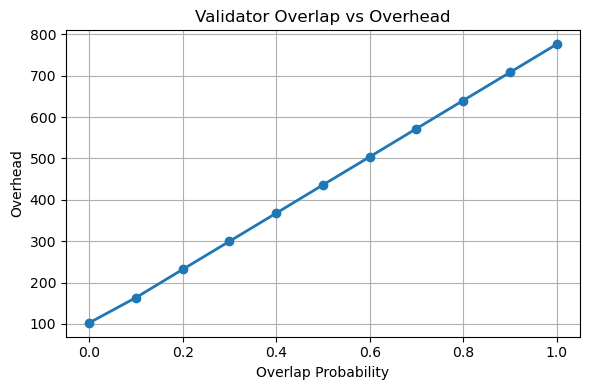

In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt

# too dangerous, compromsie prob too high

def simulate_v3(N=100, S=10, f=0.4, p=0.3, a=0.5, trials=5000,
                attack_bias=0.8, target_shard_fraction=0.3):

    compromised_count = 0
    total_overhead = 0

    for _ in range(trials):
        validators = list(range(N))
        attackers = set(random.sample(validators, int(f * N)))

        shards = {i: [] for i in range(S)}

        # 🎯 Adversary selects target shards
        num_target_shards = max(1, int(target_shard_fraction * S))
        target_shards = set(random.sample(range(S), num_target_shards))

        for v in validators:
            for s in range(S):

                if v in attackers:
                    # 🔥 Adversarial behavior
                    if s in target_shards:
                        prob = p + attack_bias * (1 - p)  # boosted probability
                    else:
                        prob = p * (1 - attack_bias)      # reduced probability
                else:
                    # Honest behavior
                    prob = p

                if random.random() < prob:
                    shards[s].append(v)
                    total_overhead += 1

        # Avoid empty shards
        for s in range(S):
            if len(shards[s]) == 0:
                v = random.choice(validators)
                shards[s].append(v)
                total_overhead += 1

        # Check compromise
        compromised = False
        for shard_vals in shards.values():
            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            if attackers_in_shard / len(shard_vals) >= a:
                compromised = True
                break

        if compromised:
            compromised_count += 1

    compromise_prob = compromised_count / trials
    avg_overhead = total_overhead / trials

    return compromise_prob, avg_overhead


ps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []
overheads = []

for p in ps:
    prob, overhead = simulate_v3(p=p)
    results.append(prob)
    overheads.append(overhead)

# 📊 Print table
print("\nEffect of Validator Overlap on Shard Compromise Probability\n")
print("------------------------+-------------------------------+-------------------------------")
print("| Overlap Probability   | Compromise Probability        | Overhead                     |")
print("------------------------+-------------------------------+-------------------------------")

for p, r, o in zip(ps, results, overheads):
    print(f"| {p:<22}| {r:<29.3f} | {o:<25.2f}    |")

print("------------------------+-------------------------------+-------------------------------")

# 📈 Plot graph
plt.figure(figsize=(6,4))
plt.plot(ps, results, marker='o', linewidth=2)

plt.title("Validator Overlap vs Shard Compromise Probability")
plt.xlabel("Overlap Probability")
plt.ylabel("Compromise Probability")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_security_adversarial_strat.png")  # saves image
plt.show()



plt.figure(figsize=(6,4))
plt.plot(ps, overheads, marker='o', linewidth=2)

plt.title("Validator Overlap vs Overhead")
plt.xlabel("Overlap Probability")
plt.ylabel("Overhead")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_overhead.png")  # saves image
plt.show()

reacts to adversarial, adversarial is random


Effect of Validator Overlap on Shard Compromise Probability

------------------------+-------------------------------+-------------------------------
| Overlap Probability   | Compromise Probability        | Overhead                     |
------------------------+-------------------------------+-------------------------------
| 0.0                   | 0.000                         | 179.69                       |
| 0.1                   | 0.000                         | 299.46                       |
| 0.2                   | 0.000                         | 379.59                       |
| 0.3                   | 0.000                         | 457.29                       |
| 0.4                   | 0.000                         | 536.64                       |
| 0.5                   | 0.000                         | 614.92                       |
| 0.6                   | 0.000                         | 693.50                       |
| 0.7                   | 0.000                 

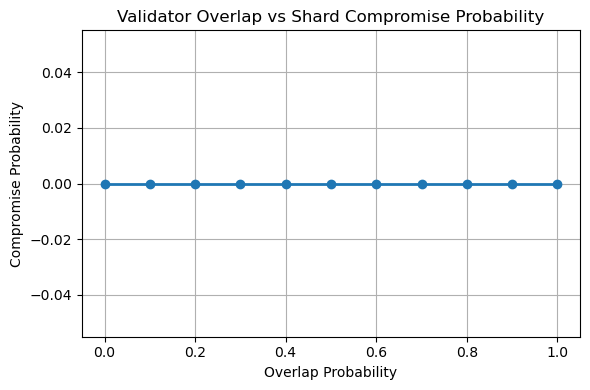

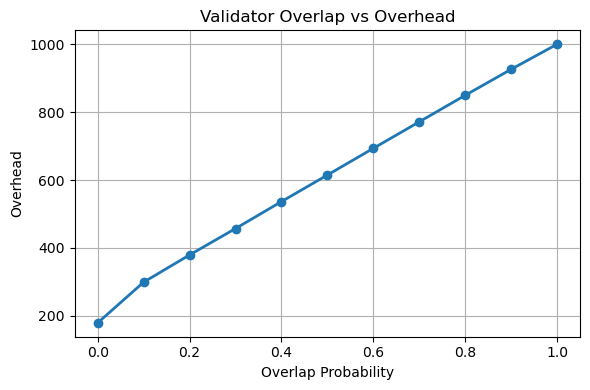

In [7]:
def simulate_v5(N=100, S=10, f=0.4, p=0.3, a=0.5, trials=5000,
                attack_bias=0.8, target_shard_fraction=0.3,
                defense_strength=0.7, suspicion_threshold=0.4):

    compromised_count = 0
    total_overhead = 0

    for _ in range(trials):
        validators = list(range(N))
        attackers = set(random.sample(validators, int(f * N)))

        shards = {i: [] for i in range(S)}

        # 🎯 Adversary selects target shards
        num_target_shards = max(1, int(target_shard_fraction * S))
        target_shards = set(random.sample(range(S), num_target_shards))

        # --- Initial assignment ---
        for v in validators:
            for s in range(S):
                if random.random() < p:
                    shards[s].append(v)
                    total_overhead += 1

        # --- Avoid empty shards ---
        for s in range(S):
            if len(shards[s]) == 0:
                v = random.choice(validators)
                shards[s].append(v)
                total_overhead += 1

        # 🔍 --- Detection phase ---
        suspicious_shards = set()
        for s, shard_vals in shards.items():
            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            ratio = attackers_in_shard / len(shard_vals)

            if ratio >= suspicion_threshold:
                suspicious_shards.add(s)

        # 🛡️ --- Defense phase ---
        honest_validators = [v for v in validators if v not in attackers]

        for v in honest_validators:
            for s in suspicious_shards:
                if v not in shards[s]:  # avoid duplicates
                    if random.random() < defense_strength:
                        shards[s].append(v)
                        total_overhead += 1

        # --- Check compromise ---
        compromised = False
        for shard_vals in shards.values():
            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            if attackers_in_shard / len(shard_vals) >= a:
                compromised = True
                break

        if compromised:
            compromised_count += 1

    compromise_prob = compromised_count / trials
    avg_overhead = total_overhead / trials

    return compromise_prob, avg_overhead


ps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []
overheads = []

for p in ps:
    prob, overhead = simulate_v5(p=p)
    results.append(prob)
    overheads.append(overhead)

# 📊 Print table
print("\nEffect of Validator Overlap on Shard Compromise Probability\n")
print("------------------------+-------------------------------+-------------------------------")
print("| Overlap Probability   | Compromise Probability        | Overhead                     |")
print("------------------------+-------------------------------+-------------------------------")

for p, r, o in zip(ps, results, overheads):
    print(f"| {p:<22}| {r:<29.3f} | {o:<25.2f}    |")

print("------------------------+-------------------------------+-------------------------------")

# 📈 Plot graph
plt.figure(figsize=(6,4))
plt.plot(ps, results, marker='o', linewidth=2)

plt.title("Validator Overlap vs Shard Compromise Probability")
plt.xlabel("Overlap Probability")
plt.ylabel("Compromise Probability")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_security_react_adversarial.png")  # saves image
plt.show()



plt.figure(figsize=(6,4))
plt.plot(ps, overheads, marker='o', linewidth=2)

plt.title("Validator Overlap vs Overhead")
plt.xlabel("Overlap Probability")
plt.ylabel("Overhead")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_overhead.png")  # saves image
plt.show()

react to adversarial activity, adversarial activity is smart


Effect of Validator Overlap on Shard Compromise Probability

------------------------+-------------------------------+-------------------------------
| Overlap Probability   | Compromise Probability        | Overhead                     |
------------------------+-------------------------------+-------------------------------
| 0.0                   | 0.045                         | 347.62                       |
| 0.1                   | 0.020                         | 288.41                       |
| 0.2                   | 0.008                         | 334.09                       |
| 0.3                   | 0.002                         | 388.36                       |
| 0.4                   | 0.000                         | 443.45                       |
| 0.5                   | 0.000                         | 498.78                       |
| 0.6                   | 0.000                         | 554.37                       |
| 0.7                   | 0.000                 

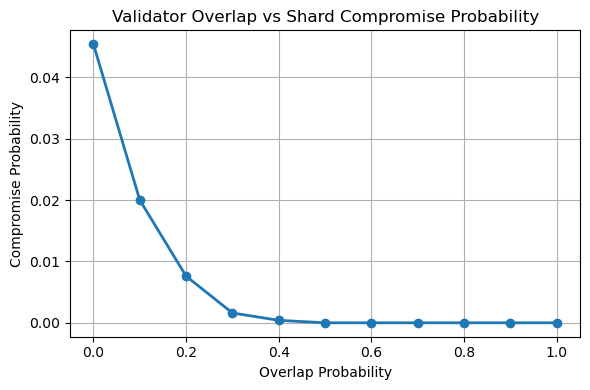

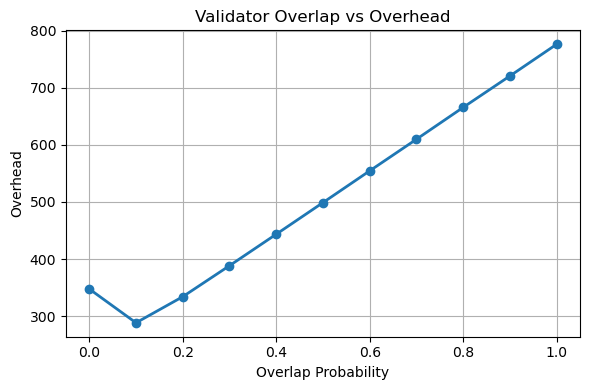

In [6]:
def simulate_v4(N=100, S=10, f=0.4, p=0.3, a=0.5, trials=5000,
                attack_bias=0.8, target_shard_fraction=0.3,
                defense_strength=0.7, suspicion_threshold=0.4):

    compromised_count = 0
    total_overhead = 0

    for _ in range(trials):
        validators = list(range(N))
        attackers = set(random.sample(validators, int(f * N)))

        shards = {i: [] for i in range(S)}

        # 🎯 Adversary selects target shards
        num_target_shards = max(1, int(target_shard_fraction * S))
        target_shards = set(random.sample(range(S), num_target_shards))

        # --- Initial assignment ---
        for v in validators:
            for s in range(S):

                if v in attackers:
                    if s in target_shards:
                        prob = p + attack_bias * (1 - p)
                    else:
                        prob = p * (1 - attack_bias)
                else:
                    prob = p

                if random.random() < prob:
                    shards[s].append(v)
                    total_overhead += 1

        # --- Avoid empty shards ---
        for s in range(S):
            if len(shards[s]) == 0:
                v = random.choice(validators)
                shards[s].append(v)
                total_overhead += 1

        # 🔍 --- Detection phase ---
        suspicious_shards = set()
        for s, shard_vals in shards.items():
            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            ratio = attackers_in_shard / len(shard_vals)

            if ratio >= suspicion_threshold:
                suspicious_shards.add(s)

        # 🛡️ --- Defense phase ---
        honest_validators = [v for v in validators if v not in attackers]

        for v in honest_validators:
            for s in suspicious_shards:
                if v not in shards[s]:  # avoid duplicates
                    if random.random() < defense_strength:
                        shards[s].append(v)
                        total_overhead += 1

        # --- Check compromise ---
        compromised = False
        for shard_vals in shards.values():
            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            if attackers_in_shard / len(shard_vals) >= a:
                compromised = True
                break

        if compromised:
            compromised_count += 1

    compromise_prob = compromised_count / trials
    avg_overhead = total_overhead / trials

    return compromise_prob, avg_overhead


ps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []
overheads = []

for p in ps:
    prob, overhead = simulate_v4(p=p)
    results.append(prob)
    overheads.append(overhead)

# 📊 Print table
print("\nEffect of Validator Overlap on Shard Compromise Probability\n")
print("------------------------+-------------------------------+-------------------------------")
print("| Overlap Probability   | Compromise Probability        | Overhead                     |")
print("------------------------+-------------------------------+-------------------------------")

for p, r, o in zip(ps, results, overheads):
    print(f"| {p:<22}| {r:<29.3f} | {o:<25.2f}    |")

print("------------------------+-------------------------------+-------------------------------")

# 📈 Plot graph
plt.figure(figsize=(6,4))
plt.plot(ps, results, marker='o', linewidth=2)

plt.title("Validator Overlap vs Shard Compromise Probability")
plt.xlabel("Overlap Probability")
plt.ylabel("Compromise Probability")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_security_react_adversarial.png")  # saves image
plt.show()



plt.figure(figsize=(6,4))
plt.plot(ps, overheads, marker='o', linewidth=2)

plt.title("Validator Overlap vs Overhead")
plt.xlabel("Overlap Probability")
plt.ylabel("Overhead")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_overhead.png")  # saves image
plt.show()


Effect of Validator Overlap on Shard Compromise Probability

------------------------+-------------------------------+-------------------------------
| Overlap Probability   | Compromise Probability        | Overhead                     |
------------------------+-------------------------------+-------------------------------
| 0.0                   | 1.000                         | 85.04                        |
| 0.1                   | 1.000                         | 163.25                       |
| 0.2                   | 0.985                         | 246.37                       |
| 0.3                   | 0.849                         | 325.46                       |
| 0.4                   | 0.564                         | 394.39                       |
| 0.5                   | 0.386                         | 449.13                       |
| 0.6                   | 0.528                         | 492.09                       |
| 0.7                   | 0.913                 

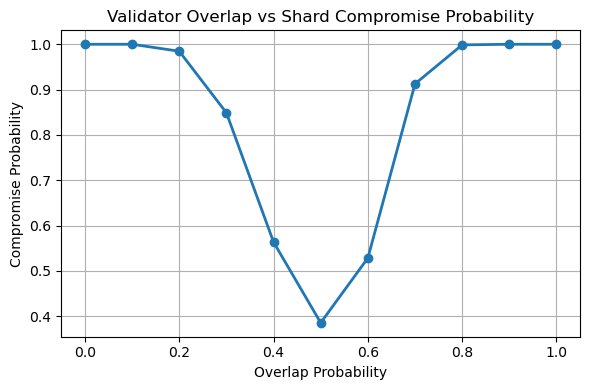

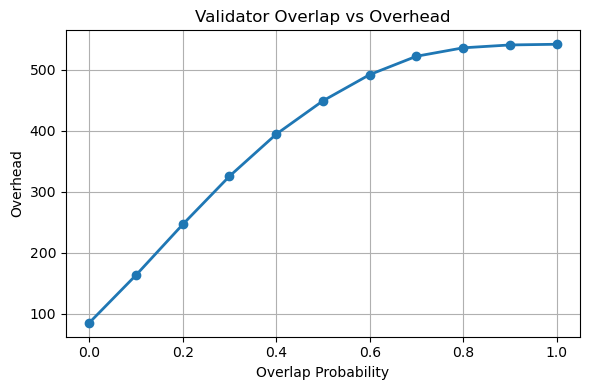

In [18]:
def simulate_v6(N=100, S=10, f=0.4, p=0.3, a=0.5, trials=5000,
                attack_bias=0.3, target_shard_fraction=0.3,
                defense_strength=0.7, suspicion_threshold=0.5,
                max_shards_per_validator=5):

    compromised_count = 0
    total_overhead = 0

    for _ in range(trials):
        validators = list(range(N))
        attackers = set(random.sample(validators, int(f * N)))

        shards = {i: [] for i in range(S)}
        validator_load = {v: set() for v in validators}

        num_target_shards = max(1, int(target_shard_fraction * S))
        target_shards = set(random.sample(range(S), num_target_shards))

        # --- Initial assignment ---
        for v in validators:
            for s in range(S):

                if len(validator_load[v]) >= max_shards_per_validator:
                    break

                if v in attackers:
                    if s in target_shards:
                        prob = p + attack_bias * (1 - p)
                    else:
                        prob = p * (1 - attack_bias)
                else:
                    prob = p

                if random.random() < prob:
                    shards[s].append(v)
                    validator_load[v].add(s)
                    total_overhead += 1

        # --- Avoid empty shards ---
        for s in range(S):
            if len(shards[s]) == 0:
                candidates = [v for v in validators if len(validator_load[v]) < max_shards_per_validator]
                if candidates:
                    v = random.choice(candidates)
                    shards[s].append(v)
                    validator_load[v].add(s)
                    total_overhead += 1

        # 🔍 Compute shard risk properly
        shard_risk = {}
        for s, shard_vals in shards.items():
            if len(shard_vals) == 0:
                shard_risk[s] = 0
                continue

            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            shard_risk[s] = attackers_in_shard / len(shard_vals)

        suspicious_shards = [s for s, r in shard_risk.items() if r >= suspicion_threshold]

        # 🛡️ Defense with reallocation
        honest_validators = [v for v in validators if v not in attackers]

        for v in honest_validators:
            if random.random() > defense_strength:
                continue

            if not suspicious_shards:
                continue

            target_s = max(suspicious_shards, key=lambda s: shard_risk[s])

            if target_s in validator_load[v]:
                continue

            # If under capacity → join
            if len(validator_load[v]) < max_shards_per_validator:
                shards[target_s].append(v)
                validator_load[v].add(target_s)
                total_overhead += 1

            else:
                # 🔁 Reallocate
                current_shards = list(validator_load[v])
                leave_s = min(current_shards, key=lambda s: shard_risk[s])

                if shard_risk[leave_s] < shard_risk[target_s]:
                    # prevent empty shard
                    if len(shards[leave_s]) > 1:
                        shards[leave_s].remove(v)
                        validator_load[v].remove(leave_s)

                        shards[target_s].append(v)
                        validator_load[v].add(target_s)

                        total_overhead += 1

        # --- Check compromise ---
        compromised = False
        for shard_vals in shards.values():
            if len(shard_vals) == 0:
                continue

            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            if attackers_in_shard / len(shard_vals) >= a:
                compromised = True
                break

        if compromised:
            compromised_count += 1

    compromise_prob = compromised_count / trials
    avg_overhead = total_overhead / trials

    return compromise_prob, avg_overhead

ps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []
overheads = []

for p in ps:
    prob, overhead = simulate_v6(p=p)
    results.append(prob)
    overheads.append(overhead)

# 📊 Print table
print("\nEffect of Validator Overlap on Shard Compromise Probability\n")
print("------------------------+-------------------------------+-------------------------------")
print("| Overlap Probability   | Compromise Probability        | Overhead                     |")
print("------------------------+-------------------------------+-------------------------------")

for p, r, o in zip(ps, results, overheads):
    print(f"| {p:<22}| {r:<29.3f} | {o:<25.2f}    |")

print("------------------------+-------------------------------+-------------------------------")

# 📈 Plot graph
plt.figure(figsize=(6,4))
plt.plot(ps, results, marker='o', linewidth=2)

plt.title("Validator Overlap vs Shard Compromise Probability")
plt.xlabel("Overlap Probability")
plt.ylabel("Compromise Probability")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_security_react_adversarial.png")  # saves image
plt.show()



plt.figure(figsize=(6,4))
plt.plot(ps, overheads, marker='o', linewidth=2)

plt.title("Validator Overlap vs Overhead")
plt.xlabel("Overlap Probability")
plt.ylabel("Overhead")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_overhead.png")  # saves image
plt.show()

In [15]:
import itertools

ps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

def score_s_curve(results):
    start = results[0]
    end = results[-1]

    slopes = [results[i+1] - results[i] for i in range(len(results)-1)]
    max_slope = max(slopes)

    return (end - start) + max_slope


best_score = -1
best_config = None
best_results = None

param_grid = itertools.product(
    [0.3, 0.5, 0.7],   # attack_bias
    [0.5, 0.7, 0.9],   # defense_strength
    [0.3, 0.4, 0.5],   # suspicion_threshold
    [2, 3, 5]          # max_shards
)

for attack_bias, defense_strength, suspicion_threshold, max_shards in param_grid:

    results = []

    for p in ps:
        prob, _ = simulate_v6(
            p=p,
            attack_bias=attack_bias,
            defense_strength=defense_strength,
            suspicion_threshold=suspicion_threshold,
            max_shards_per_validator=max_shards
        )
        results.append(prob)

    score = score_s_curve(results)

    print(f"Tested: bias={attack_bias}, defense={defense_strength}, "
          f"threshold={suspicion_threshold}, shards={max_shards} → score={score:.3f}")

    if score > best_score:
        best_score = score
        best_config = (attack_bias, defense_strength, suspicion_threshold, max_shards)
        best_results = results


print("\n🏆 BEST CONFIG:")
print(f"attack_bias={best_config[0]}")
print(f"defense_strength={best_config[1]}")
print(f"suspicion_threshold={best_config[2]}")
print(f"max_shards={best_config[3]}")
print(f"score={best_score:.3f}")

Tested: bias=0.3, defense=0.5, threshold=0.3, shards=2 → score=-0.133
Tested: bias=0.3, defense=0.5, threshold=0.3, shards=3 → score=0.045
Tested: bias=0.3, defense=0.5, threshold=0.3, shards=5 → score=0.363
Tested: bias=0.3, defense=0.5, threshold=0.4, shards=2 → score=-0.141
Tested: bias=0.3, defense=0.5, threshold=0.4, shards=3 → score=0.049
Tested: bias=0.3, defense=0.5, threshold=0.4, shards=5 → score=0.361
Tested: bias=0.3, defense=0.5, threshold=0.5, shards=2 → score=-0.151
Tested: bias=0.3, defense=0.5, threshold=0.5, shards=3 → score=0.038
Tested: bias=0.3, defense=0.5, threshold=0.5, shards=5 → score=0.358
Tested: bias=0.3, defense=0.7, threshold=0.3, shards=2 → score=-0.064
Tested: bias=0.3, defense=0.7, threshold=0.3, shards=3 → score=0.063
Tested: bias=0.3, defense=0.7, threshold=0.3, shards=5 → score=0.374
Tested: bias=0.3, defense=0.7, threshold=0.4, shards=2 → score=-0.062
Tested: bias=0.3, defense=0.7, threshold=0.4, shards=3 → score=0.057
Tested: bias=0.3, defense=0.7

Tested: bias=0.3, defense=0.5, threshold=0.3, shards=2 → score=-0.133
Tested: bias=0.3, defense=0.5, threshold=0.3, shards=3 → score=0.045
Tested: bias=0.3, defense=0.5, threshold=0.3, shards=5 → score=0.363
Tested: bias=0.3, defense=0.5, threshold=0.4, shards=2 → score=-0.141
Tested: bias=0.3, defense=0.5, threshold=0.4, shards=3 → score=0.049
Tested: bias=0.3, defense=0.5, threshold=0.4, shards=5 → score=0.361
Tested: bias=0.3, defense=0.5, threshold=0.5, shards=2 → score=-0.151
Tested: bias=0.3, defense=0.5, threshold=0.5, shards=3 → score=0.038
Tested: bias=0.3, defense=0.5, threshold=0.5, shards=5 → score=0.358
Tested: bias=0.3, defense=0.7, threshold=0.3, shards=2 → score=-0.064
Tested: bias=0.3, defense=0.7, threshold=0.3, shards=3 → score=0.063
Tested: bias=0.3, defense=0.7, threshold=0.3, shards=5 → score=0.374
Tested: bias=0.3, defense=0.7, threshold=0.4, shards=2 → score=-0.062
Tested: bias=0.3, defense=0.7, threshold=0.4, shards=3 → score=0.057
Tested: bias=0.3, defense=0.7, threshold=0.4, shards=5 → score=0.381
Tested: bias=0.3, defense=0.7, threshold=0.5, shards=2 → score=-0.076
Tested: bias=0.3, defense=0.7, threshold=0.5, shards=3 → score=0.062
Tested: bias=0.3, defense=0.7, threshold=0.5, shards=5 → score=0.386
Tested: bias=0.3, defense=0.9, threshold=0.3, shards=2 → score=-0.063
Tested: bias=0.3, defense=0.9, threshold=0.3, shards=3 → score=0.027
Tested: bias=0.3, defense=0.9, threshold=0.3, shards=5 → score=0.291
Tested: bias=0.3, defense=0.9, threshold=0.4, shards=2 → score=-0.062
Tested: bias=0.3, defense=0.9, threshold=0.4, shards=3 → score=0.032
Tested: bias=0.3, defense=0.9, threshold=0.4, shards=5 → score=0.286
Tested: bias=0.3, defense=0.9, threshold=0.5, shards=2 → score=-0.057
Tested: bias=0.3, defense=0.9, threshold=0.5, shards=3 → score=0.028
Tested: bias=0.3, defense=0.9, threshold=0.5, shards=5 → score=0.283
Tested: bias=0.5, defense=0.5, threshold=0.3, shards=2 → score=-0.167
Tested: bias=0.5, defense=0.5, threshold=0.3, shards=3 → score=-0.017
Tested: bias=0.5, defense=0.5, threshold=0.3, shards=5 → score=0.221
Tested: bias=0.5, defense=0.5, threshold=0.4, shards=2 → score=-0.187
Tested: bias=0.5, defense=0.5, threshold=0.4, shards=3 → score=-0.022
Tested: bias=0.5, defense=0.5, threshold=0.4, shards=5 → score=0.203
Tested: bias=0.5, defense=0.5, threshold=0.5, shards=2 → score=-0.171
Tested: bias=0.5, defense=0.5, threshold=0.5, shards=3 → score=-0.022
Tested: bias=0.5, defense=0.5, threshold=0.5, shards=5 → score=0.229
Tested: bias=0.5, defense=0.7, threshold=0.3, shards=2 → score=-0.102
Tested: bias=0.5, defense=0.7, threshold=0.3, shards=3 → score=-0.006
Tested: bias=0.5, defense=0.7, threshold=0.3, shards=5 → score=0.235
Tested: bias=0.5, defense=0.7, threshold=0.4, shards=2 → score=-0.098
Tested: bias=0.5, defense=0.7, threshold=0.4, shards=3 → score=-0.006
Tested: bias=0.5, defense=0.7, threshold=0.4, shards=5 → score=0.220
Tested: bias=0.5, defense=0.7, threshold=0.5, shards=2 → score=-0.105
Tested: bias=0.5, defense=0.7, threshold=0.5, shards=3 → score=-0.007
Tested: bias=0.5, defense=0.7, threshold=0.5, shards=5 → score=0.254
Tested: bias=0.5, defense=0.9, threshold=0.3, shards=2 → score=-0.066
Tested: bias=0.5, defense=0.9, threshold=0.3, shards=3 → score=-0.002
Tested: bias=0.5, defense=0.9, threshold=0.3, shards=5 → score=0.234
Tested: bias=0.5, defense=0.9, threshold=0.4, shards=2 → score=-0.069
Tested: bias=0.5, defense=0.9, threshold=0.4, shards=3 → score=0.001
Tested: bias=0.5, defense=0.9, threshold=0.4, shards=5 → score=0.238
Tested: bias=0.5, defense=0.9, threshold=0.5, shards=2 → score=-0.068
Tested: bias=0.5, defense=0.9, threshold=0.5, shards=3 → score=-0.000
Tested: bias=0.5, defense=0.9, threshold=0.5, shards=5 → score=0.232
Tested: bias=0.7, defense=0.5, threshold=0.3, shards=2 → score=-0.137
Tested: bias=0.7, defense=0.5, threshold=0.3, shards=3 → score=-0.018
Tested: bias=0.7, defense=0.5, threshold=0.3, shards=5 → score=0.112
Tested: bias=0.7, defense=0.5, threshold=0.4, shards=2 → score=-0.137
Tested: bias=0.7, defense=0.5, threshold=0.4, shards=3 → score=-0.018
Tested: bias=0.7, defense=0.5, threshold=0.4, shards=5 → score=0.098
Tested: bias=0.7, defense=0.5, threshold=0.5, shards=2 → score=-0.132
Tested: bias=0.7, defense=0.5, threshold=0.5, shards=3 → score=-0.020
Tested: bias=0.7, defense=0.5, threshold=0.5, shards=5 → score=0.106
Tested: bias=0.7, defense=0.7, threshold=0.3, shards=2 → score=-0.160
Tested: bias=0.7, defense=0.7, threshold=0.3, shards=3 → score=-0.021
Tested: bias=0.7, defense=0.7, threshold=0.3, shards=5 → score=0.134
Tested: bias=0.7, defense=0.7, threshold=0.4, shards=2 → score=-0.167
Tested: bias=0.7, defense=0.7, threshold=0.4, shards=3 → score=-0.022
Tested: bias=0.7, defense=0.7, threshold=0.4, shards=5 → score=0.140
Tested: bias=0.7, defense=0.7, threshold=0.5, shards=2 → score=-0.179
Tested: bias=0.7, defense=0.7, threshold=0.5, shards=3 → score=-0.027
Tested: bias=0.7, defense=0.7, threshold=0.5, shards=5 → score=0.126
Tested: bias=0.7, defense=0.9, threshold=0.3, shards=2 → score=-0.069
Tested: bias=0.7, defense=0.9, threshold=0.3, shards=3 → score=-0.009
Tested: bias=0.7, defense=0.9, threshold=0.3, shards=5 → score=0.094
Tested: bias=0.7, defense=0.9, threshold=0.4, shards=2 → score=-0.081
Tested: bias=0.7, defense=0.9, threshold=0.4, shards=3 → score=-0.006
Tested: bias=0.7, defense=0.9, threshold=0.4, shards=5 → score=0.090
Tested: bias=0.7, defense=0.9, threshold=0.5, shards=2 → score=-0.072
Tested: bias=0.7, defense=0.9, threshold=0.5, shards=3 → score=-0.007
Tested: bias=0.7, defense=0.9, threshold=0.5, shards=5 → score=0.088

🏆 BEST CONFIG:
attack_bias=0.3
defense_strength=0.7
suspicion_threshold=0.5
max_shards=5
score=0.386

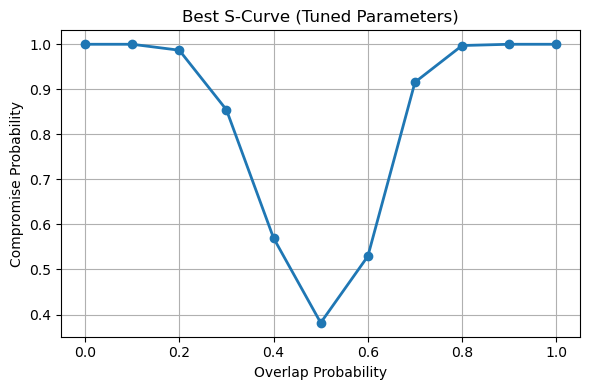

In [16]:
plt.figure(figsize=(6,4))
plt.plot(ps, best_results, marker='o', linewidth=2)

plt.title("Best S-Curve (Tuned Parameters)")
plt.xlabel("Overlap Probability")
plt.ylabel("Compromise Probability")
plt.grid(True)

plt.tight_layout()
plt.show()

bias=0.3, defense=0.5, thr=0.3, shards=2 → score=3.514, k=0.00, x0=-344176.39
bias=0.3, defense=0.5, thr=0.3, shards=3 → score=3.202, k=0.13, x0=-24.25
bias=0.3, defense=0.5, thr=0.3, shards=5 → score=1.528, k=-0.06, x0=25.19
bias=0.3, defense=0.5, thr=0.4, shards=2 → score=3.439, k=0.00, x0=-353147.02
bias=0.3, defense=0.5, thr=0.4, shards=3 → score=3.123, k=0.11, x0=-27.36
bias=0.3, defense=0.5, thr=0.4, shards=5 → score=1.571, k=-0.05, x0=33.60
bias=0.3, defense=0.5, thr=0.5, shards=2 → score=3.355, k=0.00, x0=-382643.05
bias=0.3, defense=0.5, thr=0.5, shards=3 → score=3.054, k=0.04, x0=-85.56
bias=0.3, defense=0.5, thr=0.5, shards=5 → score=1.546, k=-0.04, x0=39.10
bias=0.3, defense=0.7, thr=0.3, shards=2 → score=4.586, k=0.00, x0=-359137.97
bias=0.3, defense=0.7, thr=0.3, shards=3 → score=3.760, k=0.45, x0=-7.37
bias=0.3, defense=0.7, thr=0.3, shards=5 → score=1.664, k=0.05, x0=-32.47
bias=0.3, defense=0.7, thr=0.4, shards=2 → score=4.474, k=0.00, x0=-296297.75
bias=0.3, defense=0

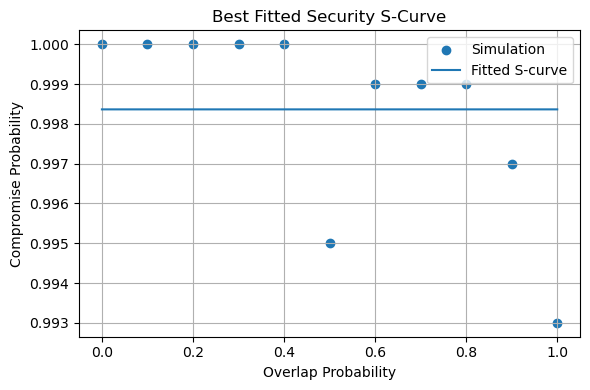


🏆 BEST CONFIG:
(0.7, 0.9, 0.4, 3)
Steepness k = 0.000
Phase shift x0 = -305662.645
Score = 6.414


In [17]:
import numpy as np
from scipy.optimize import curve_fit

def logistic(x, k, x0):
    return 1 / (1 + np.exp(-k * (x - x0)))

def fit_s_curve(ps, results):
    ps = np.array(ps)
    results = np.array(results)

    # initial guess
    p0 = [10, 0.5]

    try:
        params, _ = curve_fit(logistic, ps, results, p0=p0, maxfev=5000)
        k, x0 = params

        score = k * (1 - x0)

        return score, k, x0

    except:
        return -1, 0, 0
    
import itertools

ps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

best_score = -1
best_config = None
best_fit = None

param_grid = itertools.product(
    [0.3, 0.5, 0.7],   # attack_bias
    [0.5, 0.7, 0.9],   # defense_strength
    [0.3, 0.4, 0.5],   # suspicion_threshold
    [2, 3, 5]          # max_shards
)

for attack_bias, defense_strength, suspicion_threshold, max_shards in param_grid:

    results = []

    for p in ps:
        prob, _ = simulate_v6(
            p=p,
            attack_bias=attack_bias,
            defense_strength=defense_strength,
            suspicion_threshold=suspicion_threshold,
            max_shards_per_validator=max_shards,
            trials=1000  # speed
        )
        results.append(prob)

    score, k, x0 = fit_s_curve(ps, results)

    print(f"bias={attack_bias}, defense={defense_strength}, "
          f"thr={suspicion_threshold}, shards={max_shards} "
          f"→ score={score:.3f}, k={k:.2f}, x0={x0:.2f}")

    if score > best_score:
        best_score = score
        best_config = (attack_bias, defense_strength, suspicion_threshold, max_shards)
        best_fit = (k, x0, results)
        
k, x0, best_results = best_fit

plt.figure(figsize=(6,4))

plt.scatter(ps, best_results, label="Simulation")
plt.plot(ps, logistic(np.array(ps), k, x0), label="Fitted S-curve")

plt.title("Best Fitted Security S-Curve")
plt.xlabel("Overlap Probability")
plt.ylabel("Compromise Probability")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("\n🏆 BEST CONFIG:")
print(best_config)
print(f"Steepness k = {k:.3f}")
print(f"Phase shift x0 = {x0:.3f}")
print(f"Score = {best_score:.3f}")


Effect of Validator Overlap on Shard Compromise Probability

------------------------+-------------------------------+-------------------------------
| Overlap Probability   | Compromise Probability        | Overhead                     |
------------------------+-------------------------------+-------------------------------
| 0.0                   | 1.000                         | 315.32                       |
| 0.1                   | 1.000                         | 302.33                       |
| 0.2                   | 1.000                         | 351.24                       |
| 0.3                   | 1.000                         | 401.88                       |
| 0.4                   | 1.000                         | 452.96                       |
| 0.5                   | 1.000                         | 503.74                       |
| 0.6                   | 1.000                         | 554.33                       |
| 0.7                   | 1.000                 

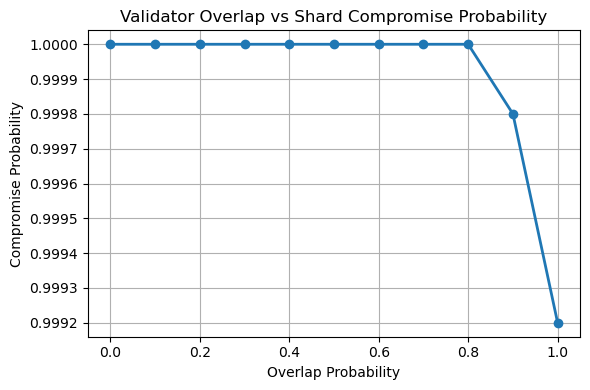

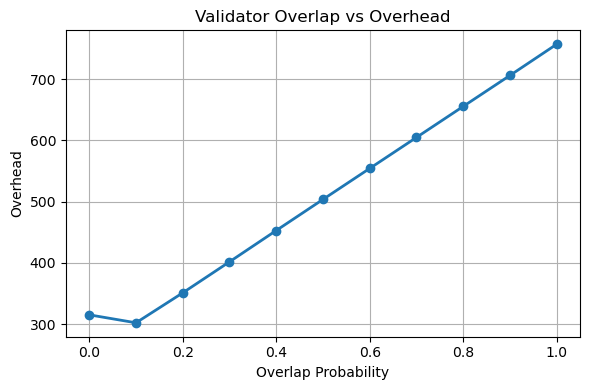

In [11]:
import math

def nakamoto_attack_success_prob(q, z):
    """
    q = attacker fraction (0 < q < 1)
    z = number of confirmations
    """
    if q >= 0.5:
        return 1.0

    p = 1 - q
    lam = z * (q / p)

    sum_prob = 0.0
    for k in range(z + 1):
        poisson = math.exp(-lam) * lam**k / math.factorial(k)
        sum_prob += poisson * (1 - (q / p) ** (z - k))

    return 1 - sum_prob

def simulate_v4(N=100, S=10, f=0.45, p=0.3, a=0.5, trials=5000,
                attack_bias=0.9, target_shard_fraction=0.4,
                defense_strength=0.4, suspicion_threshold=0.45, confirmations=3, use_nakamoto=True):

    compromised_count = 0
    total_overhead = 0

    for _ in range(trials):
        validators = list(range(N))
        attackers = set(random.sample(validators, int(f * N)))

        shards = {i: [] for i in range(S)}

        # 🎯 Adversary selects target shards
        num_target_shards = max(1, int(target_shard_fraction * S))
        target_shards = set(random.sample(range(S), num_target_shards))

        # --- Initial assignment ---
        for v in validators:
            for s in range(S):

                if v in attackers:
                    if s in target_shards:
                        prob = p + attack_bias * (1 - p)
                    else:
                        prob = p * (1 - attack_bias)
                else:
                    prob = p

                if random.random() < prob:
                    shards[s].append(v)
                    total_overhead += 1

        # --- Avoid empty shards ---
        for s in range(S):
            if len(shards[s]) == 0:
                v = random.choice(validators)
                shards[s].append(v)
                total_overhead += 1

        # 🔍 --- Detection phase ---
        suspicious_shards = set()
        for s, shard_vals in shards.items():
            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            ratio = attackers_in_shard / len(shard_vals)

            if ratio >= suspicion_threshold:
                suspicious_shards.add(s)

        # 🛡️ --- Defense phase ---
        honest_validators = [v for v in validators if v not in attackers]

        for v in honest_validators:
            for s in suspicious_shards:
                if v not in shards[s]:  # avoid duplicates
                    if random.random() < defense_strength:
                        shards[s].append(v)
                        total_overhead += 1

        # --- Check compromise ---
        compromised = False
        for shard_vals in shards.values():
            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            attacker_ratio = attackers_in_shard / len(shard_vals)

            if use_nakamoto:
                attack_prob = nakamoto_attack_success_prob(attacker_ratio, confirmations)
                if random.random() < attack_prob:
                    compromised = True
                    break
            else:
                if attacker_ratio >= a:
                    compromised = True
                    break

        if compromised:
            compromised_count += 1

    compromise_prob = compromised_count / trials
    avg_overhead = total_overhead / trials

    return compromise_prob, avg_overhead


ps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []
overheads = []

for p in ps:
    prob, overhead = simulate_v4(p=p)
    results.append(prob)
    overheads.append(overhead)

# 📊 Print table
print("\nEffect of Validator Overlap on Shard Compromise Probability\n")
print("------------------------+-------------------------------+-------------------------------")
print("| Overlap Probability   | Compromise Probability        | Overhead                     |")
print("------------------------+-------------------------------+-------------------------------")

for p, r, o in zip(ps, results, overheads):
    print(f"| {p:<22}| {r:<29.3f} | {o:<25.2f}    |")

print("------------------------+-------------------------------+-------------------------------")

# 📈 Plot graph
plt.figure(figsize=(6,4))
plt.plot(ps, results, marker='o', linewidth=2)

plt.title("Validator Overlap vs Shard Compromise Probability")
plt.xlabel("Overlap Probability")
plt.ylabel("Compromise Probability")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_security_react_adversarial.png")  # saves image
plt.show()



plt.figure(figsize=(6,4))
plt.plot(ps, overheads, marker='o', linewidth=2)

plt.title("Validator Overlap vs Overhead")
plt.xlabel("Overlap Probability")
plt.ylabel("Overhead")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_overhead.png")  # saves image
plt.show()


Effect of Validator Overlap on Shard Compromise Probability

------------------------+-------------------------------+-------------------------------
| Overlap Probability   | Compromise Probability        | Relative Overhead            |
------------------------+-------------------------------+-------------------------------
| 0.0                   | 0.986                         | 4.468                     |
| 0.1                   | 0.965                         | 4.149                     |
| 0.2                   | 0.899                         | 4.582                     |
| 0.3                   | 0.791                         | 5.018                     |
| 0.4                   | 0.644                         | 5.458                     |
| 0.5                   | 0.476                         | 5.898                     |
| 0.6                   | 0.333                         | 6.340                     |
| 0.7                   | 0.235                         | 6.779      

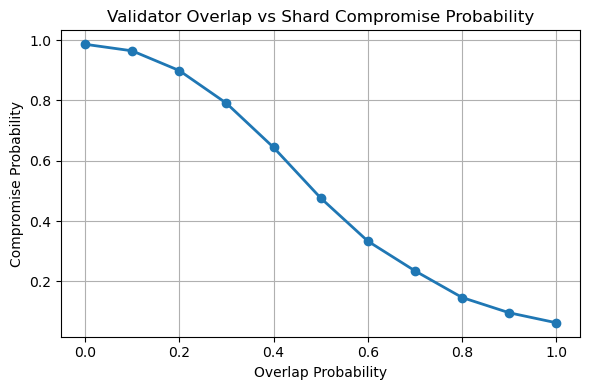

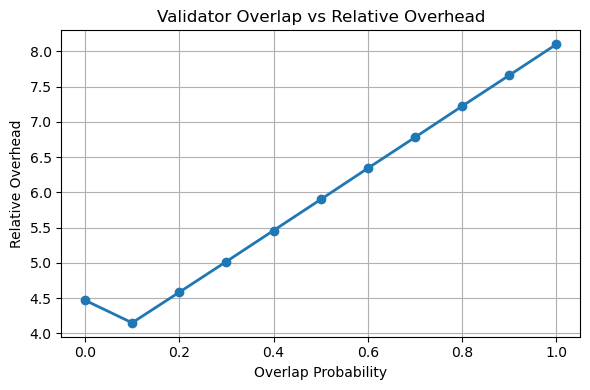

In [25]:
import math
import random
import matplotlib.pyplot as plt

def nakamoto_attack_success_prob(q, z):
    """
    q = attacker fraction (0 < q < 1)
    z = number of confirmations
    """
    if q >= 0.5:
        return 0.99

    p = 1 - q
    lam = z * (q / p)

    sum_prob = 0.0
    for k in range(z + 1):
        poisson = math.exp(-lam) * lam**k / math.factorial(k)
        sum_prob += poisson * (1 - (q / p) ** (z - k))

    return 1 - sum_prob


def simulate_v4(N=100, S=10, f=0.4, p=0.3, a=0.5, trials=5000,
                attack_bias=0.95, target_shard_fraction=0.5,
                defense_strength=0.6, suspicion_threshold=0.4,
                confirmations=10, use_nakamoto=True):

    compromised_count = 0
    total_overhead = 0

    for _ in range(trials):
        validators = list(range(N))
        attackers = set(random.sample(validators, int(f * N)))

        shards = {i: [] for i in range(S)}

        # 🎯 Adversary selects target shards
        num_target_shards = max(1, int(target_shard_fraction * S))
        target_shards = set(random.sample(range(S), num_target_shards))

        # --- Initial assignment ---
        for v in validators:
            for s in range(S):
                if v in attackers:
                    if s in target_shards:
                        prob = p + attack_bias * (1 - p)
                    else:
                        prob = p * (1 - attack_bias)
                else:
                    prob = p

                if random.random() < prob:
                    shards[s].append(v)
                    total_overhead += 1

        # --- Avoid empty shards ---
        for s in range(S):
            if len(shards[s]) == 0:
                v = random.choice(validators)
                shards[s].append(v)
                total_overhead += 1

        # 🔍 --- Detection phase ---
        suspicious_shards = set()
        for s, shard_vals in shards.items():
            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            ratio = attackers_in_shard / len(shard_vals)

            if ratio >= suspicion_threshold:
                suspicious_shards.add(s)

        # 🛡️ --- Defense phase ---
        honest_validators = [v for v in validators if v not in attackers]

        for v in honest_validators:
            for s in suspicious_shards:
                if v not in shards[s]:  # avoid duplicates
                    if random.random() < defense_strength:
                        shards[s].append(v)
                        total_overhead += 1
        
        compromised_shards = 0
        # --- Check compromise ---
        compromised = False
        for shard_vals in shards.values():
            attackers_in_shard = sum(1 for v in shard_vals if v in attackers)
            attacker_ratio = attackers_in_shard / len(shard_vals)

            if use_nakamoto:
                attack_prob = nakamoto_attack_success_prob(attacker_ratio, confirmations)
                if random.random() < attack_prob:
                    compromised_shards += 1
                    
            else:
                if attacker_ratio >= a:
                    compromised_shards += 1
                    

        if compromised_shards / S >= .4:
            compromised_count += 1

    # --- Final metrics ---
    compromise_prob = compromised_count / trials
    avg_overhead = total_overhead / trials

    # ✅ Relative overhead (Option C)
    baseline = N  # minimal: one shard per validator
    relative_overhead = avg_overhead / baseline
    return compromise_prob, relative_overhead


# --- Run experiment ---
ps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []
overheads = []

for p in ps:
    prob, overhead = simulate_v4(p=p)
    results.append(prob)
    overheads.append(overhead)


# 📊 Print table
print("\nEffect of Validator Overlap on Shard Compromise Probability\n")
print("------------------------+-------------------------------+-------------------------------")
print("| Overlap Probability   | Compromise Probability        | Relative Overhead            |")
print("------------------------+-------------------------------+-------------------------------")

for p, r, o in zip(ps, results, overheads):
    print(f"| {p:<22}| {r:<29.3f} | {o:<25.3f} |")

print("------------------------+-------------------------------+-------------------------------")


# 📈 Plot: Security
plt.figure(figsize=(6,4))
plt.plot(ps, results, marker='o', linewidth=2)

plt.title("Validator Overlap vs Shard Compromise Probability")
plt.xlabel("Overlap Probability")
plt.ylabel("Compromise Probability")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_security_react_adversarial.png")
plt.show()


# 📈 Plot: Relative Overhead
plt.figure(figsize=(6,4))
plt.plot(ps, overheads, marker='o', linewidth=2)

plt.title("Validator Overlap vs Relative Overhead")
plt.xlabel("Overlap Probability")
plt.ylabel("Relative Overhead")
plt.grid(True)

plt.tight_layout()
plt.savefig("overlap_vs_overhead.png")
plt.show()

In [31]:
import numpy as np

data = np.array([
    [4.468, 0.986],
    [4.149, 0.965],
    [4.582, 0.899],
    [5.018, 0.791],
    [5.458, 0.644],
    [5.898, 0.476],
    [6.340, 0.333],
    [6.779, 0.235],
    [7.221, 0.146],
    [7.659, 0.096],
    [8.099, 0.063],
])

overhead = data[:,0]
prob = data[:,1]

# normalize both (important)
oh = (overhead - overhead.min()) / (overhead.max() - overhead.min())
pr = (prob - prob.min()) / (prob.max() - prob.min())

score = oh + pr

best = data[np.argmin(score)]

print("Best trade-off point:")
print("Overhead:", best[0])
print("Compromise probability:", best[1])

Best trade-off point:
Overhead: 6.34
Compromise probability: 0.333


In [36]:
import numpy as np

data = np.array([
    [4.468, 0.986],
    [4.149, 0.965],
    [4.582, 0.899],
    [5.018, 0.791],
    [5.458, 0.644],
    [5.898, 0.476],
    [6.340, 0.333],
    [6.779, 0.235],
    [7.221, 0.146],
    [7.659, 0.096],
    [8.099, 0.063],
])

# -----------------------------
# STEP 1: Pareto front
# -----------------------------
def pareto_front(points):
    is_pareto = np.ones(len(points), dtype=bool)

    for i, a in enumerate(points):
        for j, b in enumerate(points):
            if j == i:
                continue
            # b dominates a if both are <= and at least one is <
            if (b[0] <= a[0] and b[1] <= a[1]) and (b[0] < a[0] or b[1] < a[1]):
                is_pareto[i] = False
                break

    return points[is_pareto]

front = pareto_front(data)

# -----------------------------
# STEP 2: normalize (important!)
# -----------------------------
f = front.copy()

overhead = f[:, 0]
prob = f[:, 1]

oh_norm = (overhead - overhead.min()) / (overhead.max() - overhead.min())
pr_norm = (prob - prob.min()) / (prob.max() - prob.min())

# -----------------------------
# STEP 3: distance to ideal point (0,0)
# -----------------------------
alpha = 5.0  # security weight (try 2–5)

dist = np.sqrt(oh_norm**2 + alpha * pr_norm**2)
best = f[np.argmin(dist)]

print("Pareto front:")
print(front)

print("\nBest balanced trade-off:")
print("Overhead:", best[0])
print("Compromise probability:", best[1])

Pareto front:
[[4.149 0.965]
 [4.582 0.899]
 [5.018 0.791]
 [5.458 0.644]
 [5.898 0.476]
 [6.34  0.333]
 [6.779 0.235]
 [7.221 0.146]
 [7.659 0.096]
 [8.099 0.063]]

Best balanced trade-off:
Overhead: 6.779
Compromise probability: 0.235
